── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Spearman(F_N, PP_mgC_m2_d) = 0.98 (n=185)
  time_month FN_mmolN_m2_d PP_mgC_m2_d depth_cutoff   Temp_C
1    05-1996     21.339086    7865.054     18.98266 22.32762
2    01-1997     10.789882    4532.805     19.19579 23.88730
3    02-1999     10.124159    3731.272     21.67364 22.23148
4    03-1998      9.690341    3563.918     14.50000 22.19515
5    03-2001      9.650513    3388.723     16.40000 21.55465
6    03-2012      8.678883    3102.960     12.40000 21.78471
# A tibble: 6 × 9
  time_month FN_mmolN_m2_d PP_mgC_m2_d depth_cutoff n_raw n_raw_in_euz
  <chr>              <dbl>       <dbl>        <dbl> <int>        <int>
1 05-1996            21.3        7865.         19.0     5            3
2 01-1997            10.8        4533.         19.2     5            3
3 02-1999            10.1        3731.         21.7     5            3
4 03-1998             9.69       3564.         14.5     5            2
5 03-2001             9.65       3389.         16.4     5            3
6 03-2012       

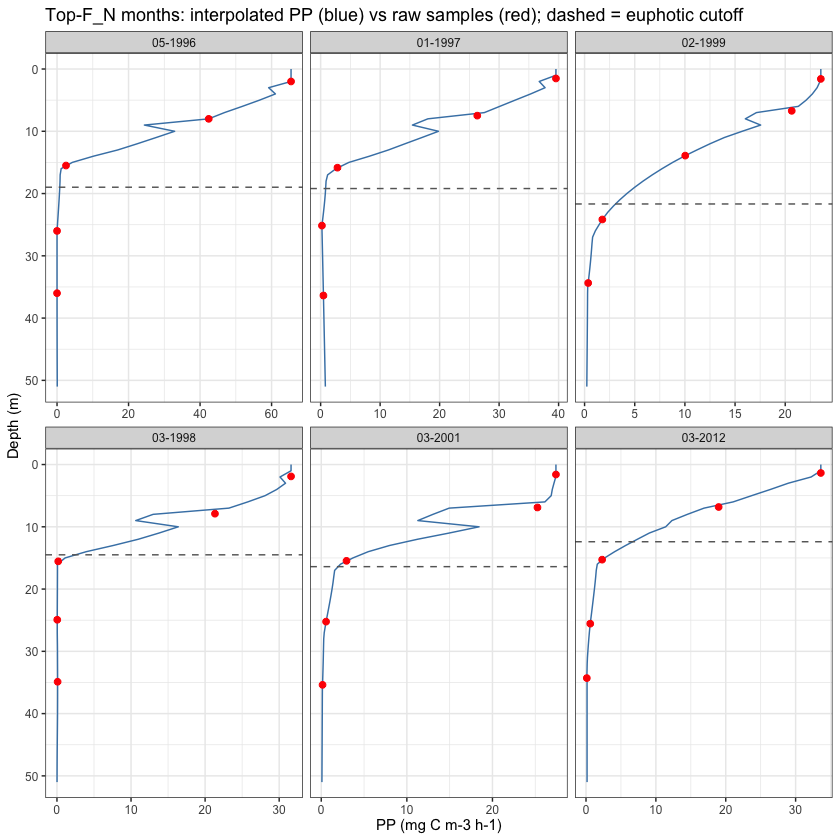

In [1]:
# Are the highest-F_N (≈ highest-PP) months backed by real PP data, or interpolation artefacts?
library(tidyverse)
K <- 6  # top months to inspect

# 1. Monthly CSV — confirm max-F_N coincides with max-PP, grab the top months
m <- read.csv("../processed/cariaco_monthly_euphotic_dynamic.csv") %>%
  filter(!is.na(FN_mmolN_m2_d))
cat(sprintf("Spearman(F_N, PP_mgC_m2_d) = %.2f (n=%d)\n",
            cor(m$FN_mmolN_m2_d, m$PP_mgC_m2_d, method = "spearman", use = "complete.obs"),
            sum(!is.na(m$PP_mgC_m2_d))))
top <- m %>% arrange(desc(FN_mmolN_m2_d)) %>% slice(1:K)
print(top %>% select(time_month, FN_mmolN_m2_d, PP_mgC_m2_d, depth_cutoff, Temp_C))
top_months <- top$time_month
dmax <- max(top$depth_cutoff, na.rm = TRUE) + 30

# 2. raw native-depth PP samples + 3. interpolated 1 m PP profiles
raw <- readRDS("../processed/Niskin_cleaned.rds") %>%
  transmute(date, month = format(date, "%m-%Y"), depth, PP = PrimaryProductivity) %>%
  filter(month %in% top_months, !is.na(PP), depth <= dmax)
intp <- readRDS("../processed/Niskin_depth_profiles.rds") %>%
  transmute(date, month = format(date, "%m-%Y"), depth, PP = PrimaryProductivity) %>%
  filter(month %in% top_months, depth <= dmax)
cut_df <- top %>% transmute(month = time_month, depth_cutoff)

# 4. plot: interpolated line (blue) vs raw samples (red), euphotic cutoff dashed
ggplot() +
  geom_path(data = intp, aes(PP, depth, group = date), color = "steelblue") +
  geom_point(data = raw, aes(PP, depth), color = "red", size = 1.6) +
  geom_hline(data = cut_df, aes(yintercept = depth_cutoff), linetype = "dashed", color = "grey40") +
  scale_y_reverse() +
  facet_wrap(~ factor(month, levels = top_months), scales = "free_x") +
  labs(x = "PP (mg C m-3 h-1)", y = "Depth (m)",
       title = "Top-F_N months: interpolated PP (blue) vs raw samples (red); dashed = euphotic cutoff") +
  theme_bw(base_size = 9)

# 5. per-month support diagnostics
diag <- top %>% rowwise() %>%
  mutate(
    n_raw        = sum(raw$month == time_month),
    n_raw_in_euz = sum(raw$month == time_month & raw$depth <= depth_cutoff),
    shallowest   = ifelse(n_raw > 0, min(raw$depth[raw$month == time_month]), NA),
    deepest      = ifelse(n_raw > 0, max(raw$depth[raw$month == time_month]), NA),
    extrapolated_below = deepest < depth_cutoff
  ) %>% ungroup() %>%
  select(time_month, FN_mmolN_m2_d, PP_mgC_m2_d, depth_cutoff,
         n_raw, n_raw_in_euz, shallowest, deepest, extrapolated_below)
print(diag)

In [4]:
library(tidyverse)
clean <- readRDS("../processed/Niskin_cleaned.rds")

cat("=== 05-1996 raw PP samples ===\n")
clean %>%
  filter(format(date, "%m-%Y") == "05-1996", !is.na(PrimaryProductivity)) %>%
  arrange(date, depth) %>%
  select(date, depth, PrimaryProductivity, Chlorophyll, Temperature) %>%
  as_tibble() %>% print(n = Inf)

# how extreme is its surface PP vs all surface (<=5 m) samples?
surf <- clean %>% filter(depth <= 5, !is.na(PrimaryProductivity))
cat(sprintf("\nSurface PP (<=5 m) across all months: median %.1f | 90th %.1f | 99th %.1f | max %.1f mgC m-3 h-1\n",
            median(surf$PrimaryProductivity), quantile(surf$PrimaryProductivity, .90),
            quantile(surf$PrimaryProductivity, .99), max(surf$PrimaryProductivity)))

=== 05-1996 raw PP samples ===
# A tibble: 8 × 5
  date       depth PrimaryProductivity Chlorophyll Temperature
  <date>     <dbl>               <dbl>       <dbl>       <dbl>
1 1996-05-09   2               65.4         6.44          23.2
2 1996-05-09   8               42.4         5.80          22.8
3 1996-05-09  15.5              2.51        1.94          21.2
4 1996-05-09  26                0           0.130         21.0
5 1996-05-09  36                0           0.104         20.9
6 1996-05-09  55                0.0704      0.120         20.8
7 1996-05-09  75.5              0           0.0658        20.4
8 1996-05-09 101                0.0210      0.0459        20.0

Surface PP (<=5 m) across all months: median 2.1 | 90th 13.3 | 99th 33.2 | max 65.4 mgC m-3 h-1


In [5]:
library(tidyverse)
source("../interpolateData.r")   # prepdataframe(), interpolateDF()

m     <- read.csv("../processed/cariaco_monthly_euphotic_dynamic.csv")
cut_T <- m %>% transmute(time_month, depth_cutoff, Temp_C)
raw   <- readRDS("../processed/Niskin_cleaned.rds")

integrate_FN <- function(func, label) {
  interpolateDF(prepdataframe(raw, "PrimaryProductivity"), func = func, surface_fix = TRUE) %>%
    mutate(time_month = format(date, "%m-%Y")) %>%
    left_join(cut_T, by = "time_month") %>%
    filter(!is.na(depth_cutoff), depth >= 0, depth <= depth_cutoff) %>%
    group_by(date, time_month, depth_cutoff, Temp_C) %>%
    summarize(PP = mean(value_int, na.rm = TRUE) * first(depth_cutoff) * 12, .groups = "drop") %>%
    group_by(time_month, Temp_C) %>%
    summarize(PP = mean(PP, na.rm = TRUE), .groups = "drop") %>%
    mutate(f = (0.5857 - 0.0165 * Temp_C) * PP / (51.7 + PP),
           FN = f * PP / 12.01 * (16 / 106), method = label) %>%
    select(time_month, !!paste0("FN_", label) := FN)
}

cmp <- full_join(integrate_FN("unesco", "unesco"), integrate_FN("linear", "linear"),
                 by = "time_month") %>%
  mutate(ratio = FN_linear / FN_unesco) %>% arrange(desc(FN_unesco))

cat("Top-F_N months, unesco vs linear:\n")
print(head(cmp, 10))
cat(sprintf("\nMedian FN_linear/FN_unesco (all months): %.2f\n", median(cmp$ratio, na.rm = TRUE)))
cat(sprintf("Spearman(unesco, linear): %.3f\n",
            cor(cmp$FN_unesco, cmp$FN_linear, method = "spearman", use = "complete.obs")))

Lade nötiges Paket: gsw



Top-F_N months, unesco vs linear:
# A tibble: 10 × 4
   time_month FN_unesco FN_linear ratio
   <chr>          <dbl>     <dbl> <dbl>
 1 05-1996        21.3      21.6   1.01
 2 01-1997        10.8      11.2   1.03
 3 02-1999        10.1      10.5   1.03
 4 03-1998         9.69      9.95  1.03
 5 03-2001         9.65     10.6   1.10
 6 03-2012         8.68      9.04  1.04
 7 02-2002         8.36      9.05  1.08
 8 02-2007         7.79      8.42  1.08
 9 03-2002         6.95      7.15  1.03
10 02-2001         6.87      7.62  1.11

Median FN_linear/FN_unesco (all months): 1.02
Spearman(unesco, linear): 0.998
